# Machine Learning & Deep Learning Lab


# CSE 414

# Student Performance Prediction System

## 1. Install and Import Libraries


In [66]:
!pip install shap joblib -q

import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Google Drive Setup and File Paths


In [67]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped or not running in Colab:", e)

PROJECT_DIR = "/content/drive/MyDrive/student_project"
CSV_FILE_NAME = "student_performance_updated_1000.csv"
MODEL_FILE_NAME = "student_performance_final_system.pkl"

os.makedirs(PROJECT_DIR, exist_ok=True)

CSV_PATH = os.path.join(PROJECT_DIR, CSV_FILE_NAME)
MODEL_PATH = os.path.join(PROJECT_DIR, MODEL_FILE_NAME)

print("Project folder:", PROJECT_DIR)
print("CSV path:", CSV_PATH)
print("Model path:", MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/student_project
CSV path: /content/drive/MyDrive/student_project/student_performance_updated_1000.csv
Model path: /content/drive/MyDrive/student_project/student_performance_final_system.pkl


## 3. Load Dataset



In [68]:
if not os.path.exists(CSV_PATH):
    print("CSV not found in Google Drive.")
    print("Upload the CSV file now. It will be saved permanently in Drive.")
    try:
        from google.colab import files
        uploaded = files.upload()

        if len(uploaded) == 0:
            raise FileNotFoundError("No file uploaded.")

        uploaded_file_name = list(uploaded.keys())[0]
        df = pd.read_csv(uploaded_file_name)
        df.to_csv(CSV_PATH, index=False)
        print(f"CSV uploaded and saved to Drive: {CSV_PATH}")

    except Exception as e:
        raise FileNotFoundError(
            f"CSV file not found at {CSV_PATH}. Please upload the file to Drive manually."
        ) from e
else:
    df = pd.read_csv(CSV_PATH)
    print("CSV loaded from Google Drive.")

print("Dataset shape:", df.shape)
display(df.head())

CSV loaded from Google Drive.
Dataset shape: (1000, 12)


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


## 4. Dataset Overview

In [69]:
print("Dataset information:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all").T)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


None


Missing values:


,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24



Duplicate rows: 0

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,960.0,NaN,NaN,NaN,5416.019792,2653.748319,1.0,3113.5,5396.5,7754.75,9998.0
Name,966,962,Erica Miller,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,952,2,Male,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AttendanceRate,960.0,NaN,NaN,NaN,85.510417,7.332125,70.0,82.0,88.0,91.0,95.0
StudyHoursPerWeek,950.0,NaN,NaN,NaN,17.630526,6.272132,8.0,12.0,18.0,22.0,30.0
PreviousGrade,967.0,NaN,NaN,NaN,77.598759,10.00664,60.0,70.0,78.0,86.0,90.0
ExtracurricularActivities,957.0,NaN,NaN,NaN,1.520376,1.046439,0.0,1.0,1.0,2.0,3.0
ParentalSupport,978,3,High,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FinalGrade,960.0,NaN,NaN,NaN,80.030208,9.493652,62.0,72.0,80.0,88.0,92.0
Study Hours,976.0,NaN,NaN,NaN,2.406967,1.620267,-5.0,1.2,2.5,3.7,5.0


## 5. Create Target Variables

- **Pass/Fail target:** `Performance`
- **Marks target:** `FinalGrade`

Rule:
- FinalGrade >= 70 → Pass
- FinalGrade < 70 → Fail

In [70]:
if "FinalGrade" not in df.columns:
    raise ValueError("FinalGrade column not found. This project needs FinalGrade for target creation.")

PASS_MARK = 70

df = df.copy()

missing_final_grade = df["FinalGrade"].isna().sum()
print("Missing FinalGrade values before cleaning:", missing_final_grade)

df = df.dropna(subset=["FinalGrade"]).reset_index(drop=True)


df["FinalGrade"] = pd.to_numeric(df["FinalGrade"], errors="coerce")
df = df.dropna(subset=["FinalGrade"]).reset_index(drop=True)

# Create Pass/Fail target
# FinalGrade >= 70 -> Pass (1), otherwise Fail (0)
df["Performance"] = (df["FinalGrade"] >= PASS_MARK).astype(int)

print("Target created successfully.")
print("Pass mark threshold:", PASS_MARK)
print("Rows after removing missing FinalGrade:", df.shape[0])
print("Missing FinalGrade values after cleaning:", df["FinalGrade"].isna().sum())

display(df["Performance"].value_counts().rename(index={0: "Fail", 1: "Pass"}))
display(df[["FinalGrade", "Performance"]].head())


Missing FinalGrade values before cleaning: 40
Target created successfully.
Pass mark threshold: 70
Rows after removing missing FinalGrade: 960
Missing FinalGrade values after cleaning: 0


,count
Performance,
Pass,777
Fail,183


,FinalGrade,Performance
0,80.0,1
1,87.0,1
2,68.0,0
3,92.0,1
4,85.0,1


## 6. Preprocessing Setup



In [71]:
columns_to_drop = ["StudentID", "Name", "FinalGrade"]
existing_drop_cols = [col for col in columns_to_drop if col in df.columns]

df_model = df.drop(columns=existing_drop_cols)

X = df_model.drop("Performance", axis=1)
y = df_model["Performance"]
y_marks = df["FinalGrade"]

# Safety check: regression target must not contain NaN.
if y_marks.isna().sum() > 0:
    raise ValueError("y_marks contains NaN. Please run the target cleaning cell again.")

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Dropped columns:", existing_drop_cols)
print("Total input features:", X.shape[1])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Missing values in marks target:", y_marks.isna().sum())

display(X.head())


Dropped columns: ['StudentID', 'Name', 'FinalGrade']
Total input features: 9
Numeric features: ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'Study Hours', 'Attendance (%)']
Categorical features: ['Gender', 'ParentalSupport', 'Online Classes Taken']
Missing values in marks target: 0


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Study Hours,Attendance (%),Online Classes Taken
0,Male,85.0,15.0,78.0,1.0,High,4.8,59.0,False
1,Female,90.0,20.0,85.0,2.0,Medium,2.2,70.0,True
2,Male,78.0,10.0,65.0,0.0,Low,4.6,92.0,False
3,Male,92.0,25.0,90.0,3.0,High,2.9,96.0,False
4,Female,NaN,18.0,82.0,2.0,Medium,4.1,97.0,True


## 7. Train-Test Split

In [72]:
X_train, X_test, y_train, y_test, y_marks_train, y_marks_test = train_test_split(
    X,
    y,
    y_marks,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).rename(index={0: "Fail", 1: "Pass"}).round(3))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).rename(index={0: "Fail", 1: "Pass"}).round(3))

Training set shape: (768, 9)
Testing set shape: (192, 9)

Training target distribution:


,proportion
Performance,
Pass,0.81
Fail,0.19



Testing target distribution:


,proportion
Performance,
Pass,0.807
Fail,0.193


## 8. Helper Functions

In [73]:
def make_one_hot_encoder():
    # Create OneHotEncoder compatible with old and new sklearn versions.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale_numeric=True):
    # Build preprocessing pipeline for numeric and categorical columns.
    numeric_steps = [("imputer", SimpleImputer(strategy="mean"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder())
    ])

    transformers = []
    if len(numeric_features) > 0:
        transformers.append(("num", numeric_transformer, numeric_features))
    if len(categorical_features) > 0:
        transformers.append(("cat", categorical_transformer, categorical_features))

    return ColumnTransformer(transformers=transformers)


def get_feature_names_from_preprocessor(fitted_preprocessor):
    # Get final feature names after preprocessing and one-hot encoding.
    feature_names_after_preprocessing = []

    if len(numeric_features) > 0 and "num" in fitted_preprocessor.named_transformers_:
        feature_names_after_preprocessing.extend(numeric_features)

    if len(categorical_features) > 0 and "cat" in fitted_preprocessor.named_transformers_:
        cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["encoder"]
        encoded_cat_features = encoder.get_feature_names_out(categorical_features)
        feature_names_after_preprocessing.extend(encoded_cat_features)

    return np.array(feature_names_after_preprocessing)


def evaluate_classification_model(model_name, pipeline):
    # Train classification model and return evaluation metrics.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    }

    # Class-wise recall is important here because Fail class can be under-detected.
    metrics["fail_recall"] = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    metrics["pass_recall"] = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    metrics["cv_f1_mean"] = cv_scores.mean()
    metrics["cv_f1_std"] = cv_scores.std()

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print("Accuracy     :", round(metrics["accuracy"], 4))
    print("Precision    :", round(metrics["precision"], 4))
    print("Recall       :", round(metrics["recall"], 4))
    print("F1 Score     :", round(metrics["f1_score"], 4))
    print("Fail Recall  :", round(metrics["fail_recall"], 4))
    print("Pass Recall  :", round(metrics["pass_recall"], 4))
    print("CV F1        :", round(metrics["cv_f1_mean"], 4), "+/-", round(metrics["cv_f1_std"], 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"], zero_division=0))

    return metrics, y_pred, pipeline


def evaluate_regression_model(model_name, pipeline):
    # Train regression model and return marks prediction metrics.
    # Regression target cannot contain NaN. This check gives a clear error message if cleaning was skipped.
    if pd.Series(y_marks_train).isna().sum() > 0 or pd.Series(y_marks_test).isna().sum() > 0:
        raise ValueError("Marks target contains NaN. Run the FinalGrade cleaning cell before train-test split.")

    pipeline.fit(X_train, y_marks_train)
    marks_pred = pipeline.predict(X_test)
    marks_pred = np.clip(marks_pred, 0, 100)

    metrics = {
        "mae": mean_absolute_error(y_marks_test, marks_pred),
        "rmse": np.sqrt(mean_squared_error(y_marks_test, marks_pred)),
        "r2_score": r2_score(y_marks_test, marks_pred)
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipeline, X_train, y_marks_train, cv=cv, scoring="r2")
    metrics["cv_r2_mean"] = cv_scores.mean()
    metrics["cv_r2_std"] = cv_scores.std()

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print("MAE     :", round(metrics["mae"], 4))
    print("RMSE    :", round(metrics["rmse"], 4))
    print("R2 Score:", round(metrics["r2_score"], 4))
    print("CV R2   :", round(metrics["cv_r2_mean"], 4), "+/-", round(metrics["cv_r2_std"], 4))

    return metrics, marks_pred, pipeline


def generate_actionable_explanations(student_df):

    explanations = []

    improvement_rules = [
        {
            "column": "AttendanceRate",
            "threshold": 85,
            "suggestion": "Try improving attendance rate above 85%.",
            "explanation": "Better attendance may improve academic performance."
        },
        {
            "column": "Attendance (%)",
            "threshold": 85,
            "suggestion": "Try maintaining attendance above 85%.",
            "explanation": "Higher attendance percentage may improve consistency."
        },
        {
            "column": "Study Hours",
            "threshold": 6,
            "suggestion": "Increase daily study hours.",
            "explanation": "More study time may improve marks prediction."
        },
        {
            "column": "StudyHoursPerWeek",
            "threshold": 15,
            "suggestion": "Increase weekly study hours.",
            "explanation": "More weekly study hours may improve learning outcomes."
        },
        {
            "column": "PreviousGrade",
            "threshold": 80,
            "suggestion": "Focus on improving academic fundamentals.",
            "explanation": "Stronger previous academic performance supports better prediction."
        }
    ]

    for rule in improvement_rules:

        col = rule["column"]

        if col not in student_df.columns:
            continue

        try:
            current_value = float(student_df[col].iloc[0])
        except:
            continue

        if current_value < rule["threshold"]:
            explanations.append({
                "Feature": col,
                "Current Value": current_value,
                "Recommended Level": rule["threshold"],
                "Suggestion": rule["suggestion"],
                "Explanation": rule["explanation"]
            })

    if "Online Classes Taken" in student_df.columns:

        online_value = student_df["Online Classes Taken"].iloc[0]

        if online_value in [False, "No", "no", "NO", 0]:
            explanations.append({
                "Feature": "Online Classes Taken",
                "Current Value": "No",
                "Recommended Level": "Yes",
                "Suggestion": "Participate in online classes regularly.",
                "Explanation": "Online classes may improve learning support."
            })

    return pd.DataFrame(explanations)


def show_prediction_result(student_df, classification_model, marks_model, feature_importance_df=None):

    prediction = classification_model.predict(student_df)[0]
    status = "Pass" if prediction == 1 else "Fail"

    predicted_marks = float(marks_model.predict(student_df)[0])
    predicted_marks = float(np.clip(predicted_marks, 0, 100))

    print("FINAL STUDENT PERFORMANCE PREDICTION")
    print("=" * 70)
    print("Predicted Status:", status)
    print("Predicted Marks (%):", round(predicted_marks, 2))

    if hasattr(classification_model, "predict_proba"):
        probability = classification_model.predict_proba(student_df)[0]
        print("Fail Probability (%):", round(float(probability[0] * 100), 2))
        print("Pass Probability (%):", round(float(probability[1] * 100), 2))

    print("\nStudent Input Data:")
    display(student_df)

    print("\nModel Explainability:")
    print("- Feature importance shows which factors affected the model most overall.")
    print("- Actionable suggestions show weak areas that can be improved.")

    if feature_importance_df is not None:
        print("\nTop Important Features:")
        display(feature_importance_df.head(10))
    else:
        print("\nFeature importance not available.")

    recommendation_df = generate_actionable_explanations(student_df)

    print("\nActionable Improvement Suggestions:")

    if len(recommendation_df) > 0:
        pd.set_option("display.max_colwidth", None)
        display(recommendation_df)

        print("\nSimple Explanation:\n")

        for _, row in recommendation_df.iterrows():
            print(f"- {row['Feature']}")
            print(f"  Current Value      : {row['Current Value']}")
            print(f"  Recommended Level  : {row['Recommended Level']}")
            print(f"  Suggestion         : {row['Suggestion']}")
            print(f"  Explanation        : {row['Explanation']}")
            print()

    else:
        print("No major weak area detected. Current input values already look strong based on the model.")

    print("Note: These suggestions are based on model features and general academic improvement logic.")

## 9. Classification Models: Pass/Fail Prediction

Models used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The best model will be selected using F1-score.

In [74]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE
    )
}

classification_results = {}
classification_predictions = {}
trained_classification_pipelines = {}

for model_name, model in classification_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", model)
    ])

    metrics, y_pred, fitted_pipeline = evaluate_classification_model(model_name, pipeline)

    classification_results[model_name] = metrics
    classification_predictions[model_name] = y_pred
    trained_classification_pipelines[model_name] = fitted_pipeline



Logistic Regression
Accuracy     : 0.4948
Precision    : 0.79
Recall       : 0.5097
F1 Score     : 0.6196
Fail Recall  : 0.4324
Pass Recall  : 0.5097
CV F1        : 0.6286 +/- 0.0446

Classification Report:
              precision    recall  f1-score   support

        Fail       0.17      0.43      0.25        37
        Pass       0.79      0.51      0.62       155

    accuracy                           0.49       192
   macro avg       0.48      0.47      0.43       192
weighted avg       0.67      0.49      0.55       192


Decision Tree
Accuracy     : 0.6198
Precision    : 0.8015
Recall       : 0.7032
F1 Score     : 0.7491
Fail Recall  : 0.2703
Pass Recall  : 0.7032
CV F1        : 0.6803 +/- 0.0609

Classification Report:
              precision    recall  f1-score   support

        Fail       0.18      0.27      0.22        37
        Pass       0.80      0.70      0.75       155

    accuracy                           0.62       192
   macro avg       0.49      0.49      0.48

## 10. Classification Model Comparison and Best Model Selection

Classification model comparison:


,accuracy,precision,recall,f1_score,fail_recall,pass_recall,cv_f1_mean,cv_f1_std
Random Forest,0.7917,0.8108,0.9677,0.8824,0.0541,0.9677,0.8703,0.0166
Decision Tree,0.6198,0.8015,0.7032,0.7491,0.2703,0.7032,0.6803,0.0609
Logistic Regression,0.4948,0.7900,0.5097,0.6196,0.4324,0.5097,0.6286,0.0446


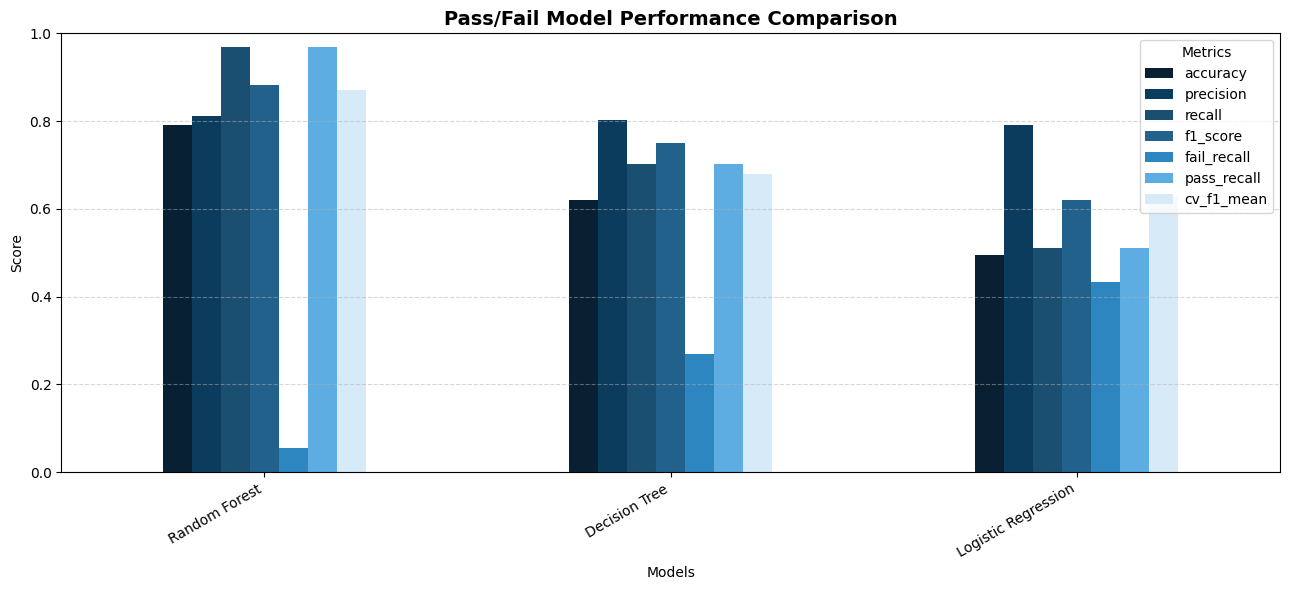

Best Pass/Fail model: Random Forest
Best F1-score: 0.8824
Fail Recall of best model: 0.0541
Pass Recall of best model: 0.9677


In [75]:
classification_results_df = pd.DataFrame(classification_results).T.sort_values(
    by="f1_score",
    ascending=False
)

print("Classification model comparison:")
display(classification_results_df.round(4))

# Professional blue theme colors
plot_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "fail_recall",
    "pass_recall",
    "cv_f1_mean"
]

colors = [
    "#082032",
    "#0B3C5D",
    "#1B4F72",
    "#21618C",
    "#2E86C1",
    "#5DADE2",
    "#D6EAF8"
]

classification_results_df[plot_columns].plot(
    kind="bar",
    figsize=(13, 6),
    color=colors
)

plt.title("Pass/Fail Model Performance Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

best_model_name = classification_results_df["f1_score"].idxmax()
best_classification_pipeline = trained_classification_pipelines[best_model_name]

print("Best Pass/Fail model:", best_model_name)
print("Best F1-score:", round(classification_results_df.loc[best_model_name, "f1_score"], 4))
print("Fail Recall of best model:", round(classification_results_df.loc[best_model_name, "fail_recall"], 4))
print("Pass Recall of best model:", round(classification_results_df.loc[best_model_name, "pass_recall"], 4))


## 11. Confusion Matrix for Best Classification Model

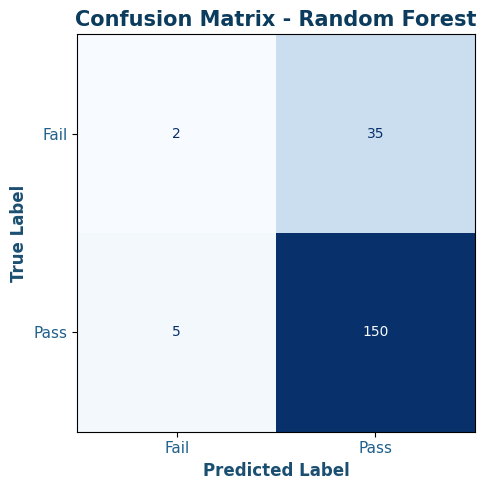

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
best_y_pred = classification_predictions[best_model_name]

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)

# Create figure
fig, ax = plt.subplots(figsize=(6, 5))

# Plot with professional blue theme
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

# Professional styling
plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=15,
    fontweight="bold",
    color="#0B3C5D"
)

plt.xlabel(
    "Predicted Label",
    fontsize=12,
    fontweight="bold",
    color="#1B4F72"
)

plt.ylabel(
    "True Label",
    fontsize=12,
    fontweight="bold",
    color="#1B4F72"
)

plt.xticks(
    fontsize=11,
    color="#21618C"
)

plt.yticks(
    fontsize=11,
    color="#21618C"
)

plt.grid(False)

plt.tight_layout()

plt.show()

## 12. Marks Percentage Prediction

Regression models used:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

The best marks model will be selected using lowest RMSE.

In [77]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    )
}

regression_results = {}
marks_predictions = {}
trained_regression_pipelines = {}

for model_name, model in regression_models.items():
    reg_pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", model)
    ])

    metrics, marks_pred, fitted_reg_pipeline = evaluate_regression_model(model_name, reg_pipeline)

    regression_results[model_name] = metrics
    marks_predictions[model_name] = marks_pred
    trained_regression_pipelines[model_name] = fitted_reg_pipeline


Linear Regression
MAE     : 8.2253
RMSE    : 9.6006
R2 Score: -0.0224
CV R2   : -0.0106 +/- 0.0121

Decision Tree Regressor
MAE     : 9.0855
RMSE    : 11.0484
R2 Score: -0.3541
CV R2   : -0.3475 +/- 0.0553

Random Forest Regressor
MAE     : 8.1237
RMSE    : 9.6479
R2 Score: -0.0326
CV R2   : -0.04 +/- 0.0212


## 13. Marks Model Comparison and Best Marks Model Selection

Marks prediction model comparison:


,mae,rmse,r2_score,cv_r2_mean,cv_r2_std
Linear Regression,8.2253,9.6006,-0.0224,-0.0106,0.0121
Random Forest Regressor,8.1237,9.6479,-0.0326,-0.0400,0.0212
Decision Tree Regressor,9.0855,11.0484,-0.3541,-0.3475,0.0553


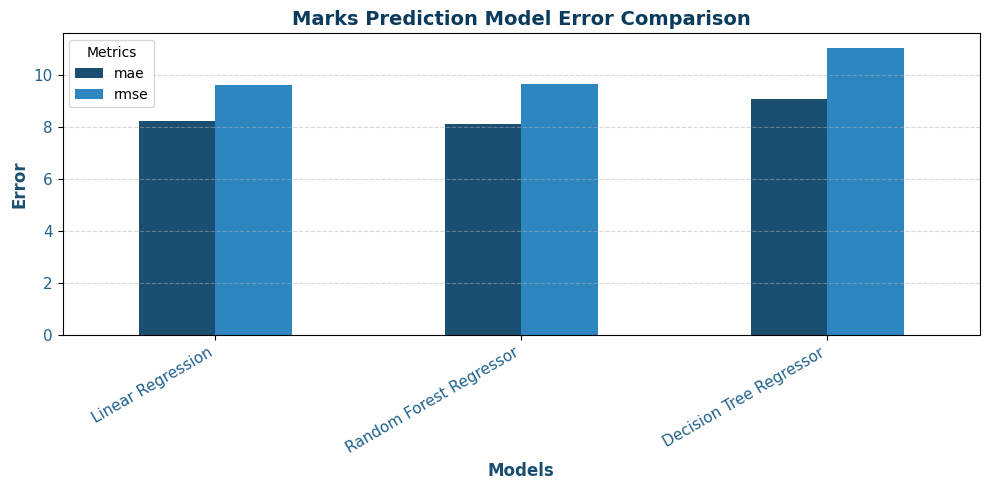

Best marks prediction model: Linear Regression
Best RMSE: 9.6006


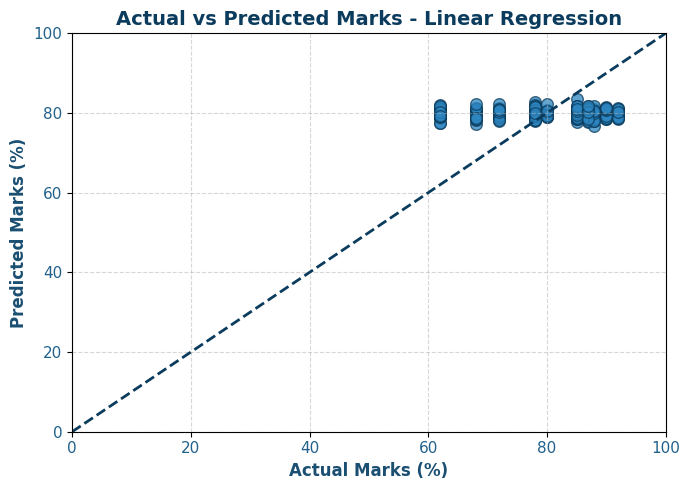

In [78]:
# Regression Results Comparison

regression_results_df = pd.DataFrame(
    regression_results
).T.sort_values(
    by="rmse",
    ascending=True
)

print("Marks prediction model comparison:")

display(regression_results_df.round(4))

colors = [
    "#0B3C5D",
    "#1B4F72",
    "#21618C",
    "#2874A6",
    "#2E86C1",
    "#5DADE2",
    "#AED6F1"
]

# Error Comparison Plot

regression_results_df[
    ["mae", "rmse"]
].plot(
    kind="bar",
    figsize=(10, 5),
    color=[colors[1], colors[4]]
)

plt.title(
    "Marks Prediction Model Error Comparison",
    fontsize=14,
    fontweight="bold",
    color="#0B3C5D"
)

plt.ylabel(
    "Error",
    fontsize=12,
    fontweight="bold",
    color="#1B4F72"
)

plt.xlabel(
    "Models",
    fontsize=12,
    fontweight="bold",
    color="#1B4F72"
)

plt.xticks(
    rotation=30,
    ha="right",
    fontsize=11,
    color="#21618C"
)

plt.yticks(
    fontsize=11,
    color="#21618C"
)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

# Best Regression Model

best_marks_model_name = regression_results_df["rmse"].idxmin()

best_marks_pipeline = trained_regression_pipelines[
    best_marks_model_name
]

print(
    "Best marks prediction model:",
    best_marks_model_name
)

print(
    "Best RMSE:",
    round(
        regression_results_df.loc[
            best_marks_model_name,
            "rmse"
        ],
        4
    )
)

# Actual vs Predicted Plot

best_marks_pred = marks_predictions[
    best_marks_model_name
]

plt.figure(figsize=(7, 5))

plt.scatter(
    y_marks_test,
    best_marks_pred,
    alpha=0.75,
    color="#2E86C1",
    edgecolors="#0B3C5D",
    s=70
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=2,
    color="#0B3C5D"
)

plt.title(
    f"Actual vs Predicted Marks - {best_marks_model_name}",
    fontsize=14,
    fontweight="bold",
    color="#0B3C5D"
)

plt.xlabel(
    "Actual Marks (%)",
    fontsize=12,
    fontweight="bold",
    color="#1B4F72"
)

plt.ylabel(
    "Predicted Marks (%)",
    fontsize=12,
    fontweight="bold",
    color="#1B4F72"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xticks(
    fontsize=11,
    color="#21618C"
)

plt.yticks(
    fontsize=11,
    color="#21618C"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

## 14. Explainability Part 1: Feature Importance

This shows which features are most important for Pass/Fail prediction.

Top important features:


,Feature,Importance
5,Attendance (%),0.215456
4,Study Hours,0.175285
1,StudyHoursPerWeek,0.132348
2,PreviousGrade,0.130098
0,AttendanceRate,0.119338
3,ExtracurricularActivities,0.068504
9,ParentalSupport_Low,0.026181
8,ParentalSupport_High,0.023303
10,ParentalSupport_Medium,0.022774
12,Online Classes Taken_True,0.022376


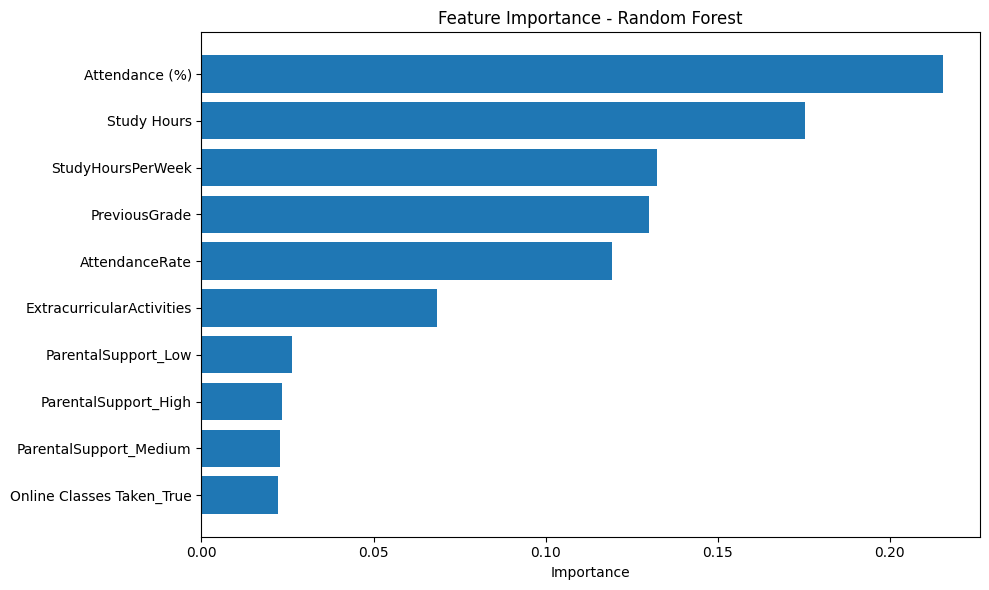

In [79]:
fitted_preprocessor = best_classification_pipeline.named_steps["preprocessor"]
feature_names_after_preprocessing = get_feature_names_from_preprocessor(fitted_preprocessor)

best_model = best_classification_pipeline.named_steps["model"]

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    importance_title = f"Feature Importance - {best_model_name}"
elif hasattr(best_model, "coef_"):
    importance_values = np.abs(best_model.coef_[0])
    importance_title = f"Absolute Coefficient Importance - {best_model_name}"
else:
    importance_values = None
    importance_title = None

if importance_values is not None:
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names_after_preprocessing,
        "Importance": importance_values
    }).sort_values(by="Importance", ascending=False)

    print("Top important features:")
    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df["Feature"].head(10), feature_importance_df["Importance"].head(10))
    plt.gca().invert_yaxis()
    plt.title(importance_title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    feature_importance_df = None
    print("This model does not provide direct feature importance or coefficients.")

## 15. Explainability Part 2: Lightweight SHAP Summary Plot

This is kept simple for demo.  
It explains how features generally influence Pass/Fail prediction.

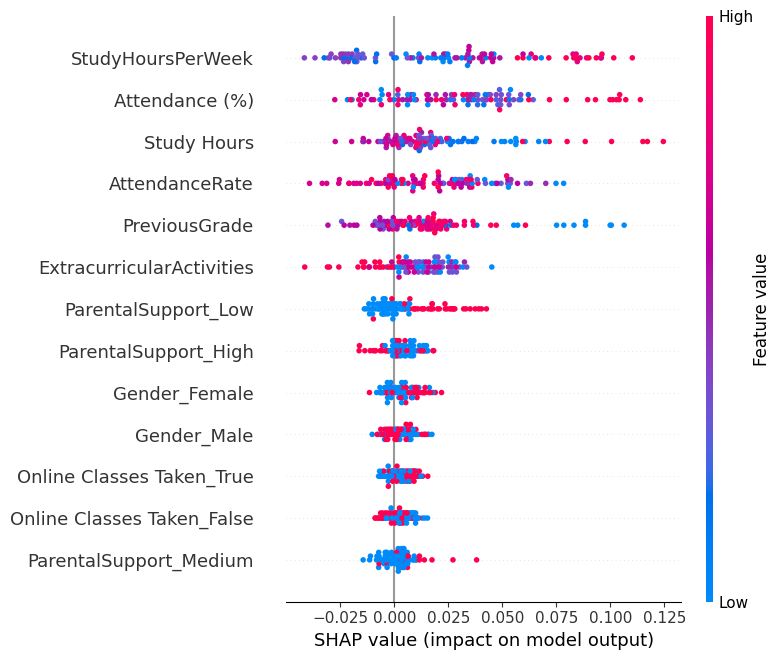

SHAP explanation generated successfully.


In [80]:
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names_after_preprocessing)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_after_preprocessing)

X_shap_sample = X_test_transformed_df.sample(
    n=min(100, len(X_test_transformed_df)),
    random_state=RANDOM_STATE
)

try:
    if best_model_name in ["Decision Tree", "Random Forest"]:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap_sample)

        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        elif len(np.array(shap_values).shape) == 3:
            shap_values_to_plot = shap_values[:, :, 1]
        else:
            shap_values_to_plot = shap_values

        shap.summary_plot(shap_values_to_plot, X_shap_sample, show=True)

    else:
        background = X_train_transformed_df.sample(
            n=min(100, len(X_train_transformed_df)),
            random_state=RANDOM_STATE
        )
        explainer = shap.LinearExplainer(best_model, background)
        shap_values_to_plot = explainer.shap_values(X_shap_sample)
        shap.summary_plot(shap_values_to_plot, X_shap_sample, show=True)

    print("SHAP explanation generated successfully.")

except Exception as e:
    print("SHAP plot could not be generated in this environment.")
    print("Reason:", e)
    print("Feature importance above will be used as the main explainability method.")

## 16. Test One Student from Test Set

In [81]:
sample_index = 0
sample_student = X_test.iloc[[sample_index]]

print("Actual Status:", "Pass" if y_test.iloc[sample_index] == 1 else "Fail")
print("Actual Marks (%):", round(float(y_marks_test.iloc[sample_index]), 2))
print()

show_prediction_result(
    student_df=sample_student,
    classification_model=best_classification_pipeline,
    marks_model=best_marks_pipeline,
    feature_importance_df=feature_importance_df
)

Actual Status: Pass
Actual Marks (%): 85.0

FINAL STUDENT PERFORMANCE PREDICTION
Predicted Status: Pass
Predicted Marks (%): 80.68
Fail Probability (%): 20.87
Pass Probability (%): 79.13

Student Input Data:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Study Hours,Attendance (%),Online Classes Taken
639,Male,78.0,30.0,78.0,2.0,High,4.7,72.0,False



Model Explainability:
- Feature importance shows which factors affected the model most overall.
- Actionable suggestions show weak areas that can be improved.

Top Important Features:


,Feature,Importance
5,Attendance (%),0.215456
4,Study Hours,0.175285
1,StudyHoursPerWeek,0.132348
2,PreviousGrade,0.130098
0,AttendanceRate,0.119338
3,ExtracurricularActivities,0.068504
9,ParentalSupport_Low,0.026181
8,ParentalSupport_High,0.023303
10,ParentalSupport_Medium,0.022774
12,Online Classes Taken_True,0.022376



Actionable Improvement Suggestions:


,Feature,Current Value,Recommended Level,Suggestion,Explanation
0,AttendanceRate,78.0,85,Try improving attendance rate above 85%.,Better attendance may improve academic performance.
1,Attendance (%),72.0,85,Try maintaining attendance above 85%.,Higher attendance percentage may improve consistency.
2,Study Hours,4.7,6,Increase daily study hours.,More study time may improve marks prediction.
3,PreviousGrade,78.0,80,Focus on improving academic fundamentals.,Stronger previous academic performance supports better prediction.
4,Online Classes Taken,No,Yes,Participate in online classes regularly.,Online classes may improve learning support.



Simple Explanation:

- AttendanceRate
  Current Value      : 78.0
  Recommended Level  : 85
  Suggestion         : Try improving attendance rate above 85%.
  Explanation        : Better attendance may improve academic performance.

- Attendance (%)
  Current Value      : 72.0
  Recommended Level  : 85
  Suggestion         : Try maintaining attendance above 85%.
  Explanation        : Higher attendance percentage may improve consistency.

- Study Hours
  Current Value      : 4.7
  Recommended Level  : 6
  Suggestion         : Increase daily study hours.
  Explanation        : More study time may improve marks prediction.

- PreviousGrade
  Current Value      : 78.0
  Recommended Level  : 80
  Suggestion         : Focus on improving academic fundamentals.
  Explanation        : Stronger previous academic performance supports better prediction.

- Online Classes Taken
  Current Value      : No
  Recommended Level  : Yes
  Suggestion         : Participate in online classes regularly.
  Ex

## 17. Save Final System to Google Drive


In [82]:
final_system = {
    "classification_model": best_classification_pipeline,
    "classification_model_name": best_model_name,
    "classification_results_df": classification_results_df,

    "marks_model": best_marks_pipeline,
    "marks_model_name": best_marks_model_name,
    "regression_results_df": regression_results_df,

    "raw_feature_names": X.columns.tolist(),
    "input_template": X.iloc[0].to_dict(),
    "feature_importance_df": feature_importance_df,

    "pass_mark": PASS_MARK
}

joblib.dump(final_system, MODEL_PATH)

print("Final system saved successfully.")
print("Saved path:", MODEL_PATH)
print("Saved Pass/Fail model:", best_model_name)
print("Saved marks model:", best_marks_model_name)

Final system saved successfully.
Saved path: /content/drive/MyDrive/student_project/student_performance_final_system.pkl
Saved Pass/Fail model: Random Forest
Saved marks model: Linear Regression


## 18. Live Manual Student Input Testing



In [83]:
loaded_system = joblib.load(MODEL_PATH)

loaded_classification_model = loaded_system["classification_model"]
loaded_marks_model = loaded_system["marks_model"]
raw_feature_names = loaded_system["raw_feature_names"]
feature_importance_df = loaded_system.get("feature_importance_df", None)

print("Enter student information:\n")

student_data = {}

student_data["Gender"] = input("Gender (Male/Female): ")
student_data["AttendanceRate"] = float(input("Attendance Rate (0-100): "))
student_data["StudyHoursPerWeek"] = float(input("Study Hours Per Week: "))
student_data["PreviousGrade"] = float(input("Previous Grade (0-100): "))
student_data["ExtracurricularActivities"] = int(input("Extracurricular Activities (1=Yes, 0=No): "))
student_data["ParentalSupport"] = input("Parental Support (Low/Medium/High): ")
student_data["Study Hours"] = float(input("Daily Study Hours: "))
student_data["Attendance (%)"] = float(input("Attendance Percentage (0-100): "))

online_input = input("Online Classes Taken? (Yes/No): ")
student_data["Online Classes Taken"] = True if online_input.strip().lower() in ["yes", "y", "true", "1"] else False

manual_student = pd.DataFrame([student_data])

# Ensure input column order matches the training system.
manual_student = manual_student.reindex(columns=raw_feature_names)

show_prediction_result(
    student_df=manual_student,
    classification_model=loaded_classification_model,
    marks_model=loaded_marks_model,
    feature_importance_df=feature_importance_df
)



Enter student information:

Gender (Male/Female): male
Attendance Rate (0-100): 89
Study Hours Per Week: 16
Previous Grade (0-100): 70
Extracurricular Activities (1=Yes, 0=No): 1
Parental Support (Low/Medium/High): low
Daily Study Hours: 6
Attendance Percentage (0-100): 89
Online Classes Taken? (Yes/No): yes
FINAL STUDENT PERFORMANCE PREDICTION
Predicted Status: Pass
Predicted Marks (%): 81.41
Fail Probability (%): 37.64
Pass Probability (%): 62.36

Student Input Data:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Study Hours,Attendance (%),Online Classes Taken
0,male,89.0,16.0,70.0,1,low,6.0,89.0,True



Model Explainability:
- Feature importance shows which factors affected the model most overall.
- Actionable suggestions show weak areas that can be improved.

Top Important Features:


,Feature,Importance
5,Attendance (%),0.215456
4,Study Hours,0.175285
1,StudyHoursPerWeek,0.132348
2,PreviousGrade,0.130098
0,AttendanceRate,0.119338
3,ExtracurricularActivities,0.068504
9,ParentalSupport_Low,0.026181
8,ParentalSupport_High,0.023303
10,ParentalSupport_Medium,0.022774
12,Online Classes Taken_True,0.022376



Actionable Improvement Suggestions:


,Feature,Current Value,Recommended Level,Suggestion,Explanation
0,PreviousGrade,70.0,80,Focus on improving academic fundamentals.,Stronger previous academic performance supports better prediction.



Simple Explanation:

- PreviousGrade
  Current Value      : 70.0
  Recommended Level  : 80
  Suggestion         : Focus on improving academic fundamentals.
  Explanation        : Stronger previous academic performance supports better prediction.

Note: These suggestions are based on model features and general academic improvement logic.


# FAST DEMO MODE


## Fast Demo Cell 1: Load Saved System Only

In [85]:
!pip install joblib -q

import os
import joblib
import numpy as np
import pandas as pd

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
except Exception as e:
    print("Drive mount skipped or not running in Colab:", e)

PROJECT_DIR = "/content/drive/MyDrive/student_project"
MODEL_FILE_NAME = "student_performance_final_system.pkl"
MODEL_PATH = os.path.join(PROJECT_DIR, MODEL_FILE_NAME)

loaded_system = joblib.load(MODEL_PATH)

loaded_classification_model = loaded_system["classification_model"]
loaded_marks_model = loaded_system["marks_model"]
raw_feature_names = loaded_system["raw_feature_names"]
feature_importance_df = loaded_system.get("feature_importance_df", None)

print("Saved system loaded successfully.")
print("Pass/Fail model:", loaded_system["classification_model_name"])
print("Marks model:", loaded_system["marks_model_name"])
print("Total input features:", len(raw_feature_names))
print("\nAvailable input columns:")
print(raw_feature_names)


def generate_actionable_explanation(student_df):
    suggestions = []

    improvement_rules = [
        {
            "column": "AttendanceRate",
            "threshold": 85,
            "suggestion": "Improve attendance rate above 85%.",
            "explanation": "Better attendance may improve academic performance."
        },
        {
            "column": "Attendance (%)",
            "threshold": 85,
            "suggestion": "Maintain attendance above 85%.",
            "explanation": "Higher attendance percentage may improve consistency."
        },
        {
            "column": "StudyHoursPerWeek",
            "threshold": 15,
            "suggestion": "Increase weekly study hours.",
            "explanation": "More weekly study time may improve learning outcomes."
        },
        {
            "column": "Study Hours",
            "threshold": 6,
            "suggestion": "Increase daily study hours.",
            "explanation": "More daily study time may improve predicted marks."
        },
        {
            "column": "PreviousGrade",
            "threshold": 80,
            "suggestion": "Focus on improving academic fundamentals.",
            "explanation": "Stronger previous academic performance supports better prediction."
        }
    ]

    for rule in improvement_rules:
        col = rule["column"]

        if col not in student_df.columns:
            continue

        try:
            current_value = float(student_df[col].iloc[0])
        except Exception:
            continue

        if current_value < rule["threshold"]:
            suggestions.append({
                "Feature": col,
                "Current Value": current_value,
                "Recommended Level": rule["threshold"],
                "Suggestion": rule["suggestion"],
                "Explanation": rule["explanation"]
            })

    if "Online Classes Taken" in student_df.columns:
        online_value = student_df["Online Classes Taken"].iloc[0]

        if online_value in [False, "False", "No", "no", "NO", 0, "0"]:
            suggestions.append({
                "Feature": "Online Classes Taken",
                "Current Value": "No",
                "Recommended Level": "Yes",
                "Suggestion": "Participate in online classes regularly.",
                "Explanation": "Online classes may improve learning support."
            })

    if "ParentalSupport" in student_df.columns:
        support_value = str(student_df["ParentalSupport"].iloc[0]).strip().lower()

        if support_value in ["low", "medium"]:
            suggestions.append({
                "Feature": "ParentalSupport",
                "Current Value": student_df["ParentalSupport"].iloc[0],
                "Recommended Level": "High",
                "Suggestion": "Increase academic support from parents/guardians.",
                "Explanation": "Better academic support may improve learning performance."
            })

    return pd.DataFrame(suggestions)


def show_prediction_result(student_df, classification_model, marks_model, feature_importance_df=None):
    prediction = classification_model.predict(student_df)[0]
    status = "Pass" if prediction == 1 else "Fail"

    predicted_marks = float(np.clip(marks_model.predict(student_df)[0], 0, 100))

    print("FINAL STUDENT PERFORMANCE PREDICTION")
    print("=" * 70)
    print("Predicted Status:", status)
    print("Predicted Marks (%):", round(predicted_marks, 2))

    print("\nStudent Input Data:")
    display(student_df)

    print("\nModel Explainability:")
    print("- Feature importance shows which factors affected the model most overall.")
    print("- Actionable suggestions show weak areas that can be improved.")

    if feature_importance_df is not None:
        print("\nTop Important Features:")
        display(feature_importance_df.head(10))
    else:
        print("Feature importance not available.")

    recommendation_df = generate_actionable_explanation(student_df)

    print("\nActionable Improvement Suggestions:")

    if len(recommendation_df) > 0:
        pd.set_option("display.max_colwidth", None)
        display(recommendation_df)

        print("\nSimple Explanation:\n")

        for _, row in recommendation_df.iterrows():
            print(f"- {row['Feature']}")
            print(f"  Current Value      : {row['Current Value']}")
            print(f"  Recommended Level  : {row['Recommended Level']}")
            print(f"  Suggestion         : {row['Suggestion']}")
            print(f"  Explanation        : {row['Explanation']}")
            print()
    else:
        print("No major weak area detected. Current input values already look strong based on the model.")

    print("Note: These suggestions are based on model features and general academic improvement logic.")

Mounted at /content/drive
Saved system loaded successfully.
Pass/Fail model: Random Forest
Marks model: Linear Regression
Total input features: 9

Available input columns:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


## Fast Demo Cell 2: Manual Student Test

In [86]:
loaded_system = joblib.load(MODEL_PATH)

loaded_classification_model = loaded_system["classification_model"]
loaded_marks_model = loaded_system["marks_model"]
raw_feature_names = loaded_system["raw_feature_names"]
feature_importance_df = loaded_system.get("feature_importance_df", None)

print("Enter student information:\n")

student_data = {
    "Gender": input("Gender (Male/Female): "),
    "AttendanceRate": float(input("Attendance Rate (0-100): ")),
    "StudyHoursPerWeek": float(input("Study Hours Per Week: ")),
    "PreviousGrade": float(input("Previous Grade (0-100): ")),
    "ExtracurricularActivities": int(input("Extracurricular Activities (1=Yes, 0=No): ")),
    "ParentalSupport": input("Parental Support (Low/Medium/High): "),
    "Study Hours": float(input("Daily Study Hours: ")),
    "Attendance (%)": float(input("Attendance Percentage (0-100): "))
}

online_input = input("Online Classes Taken? (Yes/No): ")
student_data["Online Classes Taken"] = online_input.strip().lower() in ["yes", "y", "true", "1"]

manual_student = pd.DataFrame([student_data])

manual_student = manual_student.reindex(columns=raw_feature_names)

show_prediction_result(
    student_df=manual_student,
    classification_model=loaded_classification_model,
    marks_model=loaded_marks_model,
    feature_importance_df=feature_importance_df
)

Enter student information:

Gender (Male/Female): Male
Attendance Rate (0-100): 65
Study Hours Per Week: 15
Previous Grade (0-100): 89
Extracurricular Activities (1=Yes, 0=No): 0
Parental Support (Low/Medium/High): Low
Daily Study Hours: 6
Attendance Percentage (0-100): 65
Online Classes Taken? (Yes/No): No
FINAL STUDENT PERFORMANCE PREDICTION
Predicted Status: Pass
Predicted Marks (%): 81.41

Student Input Data:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,Study Hours,Attendance (%),Online Classes Taken
0,Male,65.0,15.0,89.0,0,Low,6.0,65.0,False



Model Explainability:
- Feature importance shows which factors affected the model most overall.
- Actionable suggestions show weak areas that can be improved.

Top Important Features:


,Feature,Importance
5,Attendance (%),0.215456
4,Study Hours,0.175285
1,StudyHoursPerWeek,0.132348
2,PreviousGrade,0.130098
0,AttendanceRate,0.119338
3,ExtracurricularActivities,0.068504
9,ParentalSupport_Low,0.026181
8,ParentalSupport_High,0.023303
10,ParentalSupport_Medium,0.022774
12,Online Classes Taken_True,0.022376



Actionable Improvement Suggestions:


,Feature,Current Value,Recommended Level,Suggestion,Explanation
0,AttendanceRate,65.0,85,Improve attendance rate above 85%.,Better attendance may improve academic performance.
1,Attendance (%),65.0,85,Maintain attendance above 85%.,Higher attendance percentage may improve consistency.
2,Online Classes Taken,No,Yes,Participate in online classes regularly.,Online classes may improve learning support.
3,ParentalSupport,Low,High,Increase academic support from parents/guardians.,Better academic support may improve learning performance.



Simple Explanation:

- AttendanceRate
  Current Value      : 65.0
  Recommended Level  : 85
  Suggestion         : Improve attendance rate above 85%.
  Explanation        : Better attendance may improve academic performance.

- Attendance (%)
  Current Value      : 65.0
  Recommended Level  : 85
  Suggestion         : Maintain attendance above 85%.
  Explanation        : Higher attendance percentage may improve consistency.

- Online Classes Taken
  Current Value      : No
  Recommended Level  : Yes
  Suggestion         : Participate in online classes regularly.
  Explanation        : Online classes may improve learning support.

- ParentalSupport
  Current Value      : Low
  Recommended Level  : High
  Suggestion         : Increase academic support from parents/guardians.
  Explanation        : Better academic support may improve learning performance.

Note: These suggestions are based on model features and general academic improvement logic.


## Final Project Summary

This notebook includes:

- Dataset loading from Google Drive  
- Pass/Fail target creation  
- Logistic Regression, Decision Tree, Random Forest comparison  
- Best classification model selection  
- Marks percentage prediction using regression models  
- Explainability using Feature Importance and lightweight SHAP  
- User/manual input testing  
- Saved model system for fast demo